# AMO Case — Продуктовый аналитик

**Контекст:** пол года назад подписку подняли с 6.99 до 9.99/нед (тест показал, что конверсии не упали). CEO сомневается: цена выросла на 42%, а в реальном Revenue таких цифр нет. Наша задача — разобраться.

## Дорожная карта

| Блок | Что делаем |
|---|---|
| **0** | Загрузка + чистка (дубли, типы, sanity-check) |
| **1** | A/B: конверсии click → purchase → sub_purchase по сегментам + стат.значимость |
| **2** | LTV на 1.5 мес для 6.99 vs 9.99 (с учётом refund / chargeback / OTP) |
| **3** | Реально ли ARPU вырос на +42%? Деньги за период 26.01–16.03 |
| **4** | ROAS по сегментам (канал / регион / ценовая группа) |
| **Итог** | Вывод + рекомендация по цене |

In [22]:
# --- 1. Импорты (напиши сам) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

# --- 2. Настройки отображения (по желанию) ---
pd.set_option('display.max_columns', None)

# --- 3. Загрузка 6 CSV из папки data/ (напиши сам) ---
df_order_data = pd.read_csv('data/order_data.csv')
df_otp_data = pd.read_csv('data/otp_data.csv')
df_refunds_data = pd.read_csv('data/refunds_cb_data.csv')
df_test_data = pd.read_csv('data/test_data.csv')
df_user_data = pd.read_csv('data/user_data.csv')
df_marketing_spend_data = pd.read_csv('data/marketing_spend_data.csv')



### Быстрая проверка, что всё загрузилось

После загрузки выведи размер каждой таблицы (`.shape`) и посмотри на первые строки (`.head()`). Начни с одной таблицы — например `test_data.head()`.

In [23]:
# Проверка загрузки (напиши сам)
print(f"Данные о маркетинговых расходах: {df_marketing_spend_data.shape[0]} строк, {df_marketing_spend_data.shape[1]} столбцов")
print(f"Данные о заказах: {df_order_data.shape[0]} строк, {df_order_data.shape[1]} столбцов")
print(f"Данные об OTP: {df_otp_data.shape[0]} строк, {df_otp_data.shape[1]} столбцов")
print(f"Данные о возвратах: {df_refunds_data.shape[0]} строк, {df_refunds_data.shape[1]} столбцов")
print(f"Данные о тестах: {df_test_data.shape[0]} строк, {df_test_data.shape[1]} столбцов")
print(f"Данные о пользователях: {df_user_data.shape[0]} строк, {df_user_data.shape[1]} столбцов")



Данные о маркетинговых расходах: 609 строк, 7 столбцов
Данные о заказах: 342616 строк, 6 столбцов
Данные об OTP: 44110 строк, 3 столбцов
Данные о возвратах: 215088 строк, 5 столбцов
Данные о тестах: 127598 строк, 9 столбцов
Данные о пользователях: 215088 строк, 5 столбцов


In [24]:
display(df_marketing_spend_data.head())
display(df_order_data.head())
display(df_otp_data.head())
display(df_refunds_data.head())
display(df_test_data.head())
display(df_user_data.head())


,date,channel,country_group,group,clicks,cpc,spend
0,2025-01-05,Facebook,EU,control,2,0.6992,1.40
1,2025-01-05,Facebook,EU,test,1,0.7836,0.78
2,2025-01-05,Facebook,Tier1,test,1,0.7426,0.74
3,2025-01-05,Facebook,USA,control,4,0.7768,3.11
4,2025-01-05,Facebook,USA,test,2,0.8074,1.61


,user_uuid,date_started,Product Name,order_date,Trial Period Days,Rebill Period Days
0,9a15cd24-d957-49c6-9e83-1f5cb8897280,2025-02-19,weekly 6.99,2025-02-26,7,7
1,9a15cd24-d957-49c6-9e83-1f5cb8897280,2025-02-19,weekly 6.99,2025-03-05,7,7
2,f5fa6241-e57f-45d9-9013-ff0956fb5d91,2025-03-14,weekly 6.99,2025-03-21,7,7
3,6face9f9-76dd-44fb-bfc8-d5676071b311,2025-02-26,weekly 6.99,2025-03-05,7,7
4,30599dfe-abda-442d-9ba4-9a1c7cf9ec17,2025-02-12,weekly 9.99,2025-02-19,7,7


,user_uuid,Product Name,revenue
0,dfd3ab19-6189-4404-82e4-f1f0c0a3922c,one time payment,15
1,0b62b33e-b439-445e-9758-6f604c865609,one time payment,15
2,7802c61c-5a0d-4942-aca6-1f3908474add,one time payment,15
3,3d4ceb0e-b061-48d9-a717-4fa32e737053,one time payment,15
4,4bb69bca-52c6-4d99-be62-328cdd4430d4,one time payment,15


,user_uuid,Product Name,refund,chargeback,price
0,9a15cd24-d957-49c6-9e83-1f5cb8897280,weekly 6.99,0,0,6.99
1,f5fa6241-e57f-45d9-9013-ff0956fb5d91,weekly 6.99,0,0,6.99
2,6face9f9-76dd-44fb-bfc8-d5676071b311,weekly 6.99,0,0,6.99
3,30599dfe-abda-442d-9ba4-9a1c7cf9ec17,weekly 9.99,0,0,9.99
4,b6c932a7-174e-4ff3-8e95-17342b4e54c9,weekly 6.99,0,0,6.99


,user_id,event_date,event_name,group,country_group,platform,payment_method,product_name,channel
0,bd02dd19-1250-4902-877a-818617262946,2025-01-18,click,control,Tier1,Android,card,Weekly 6.99,Facebook
1,4c78ff37-7f18-412f-aff3-b7109100b922,2025-01-19,click,control,EU,Android,card,Weekly 6.99,Organic
2,9e2ced6a-dd70-4836-ba96-ee71c4165980,2025-01-13,click,test,USA,IOS,paypal,Weekly 9.99,Google
3,bab3f720-3ada-47a8-b9c3-e9310bd4ef7c,2025-01-13,click,test,EU,Android,paypal,Weekly 9.99,Google
4,eca01a89-0126-4d33-ac46-a0481dcd7220,2025-01-24,purchase,test,USA,IOS,card,Weekly 9.99,Facebook


,user_uuid,region,platform,payment_type,age_segment
0,9a15cd24-d957-49c6-9e83-1f5cb8897280,USA,Android,card,31-45
1,f5fa6241-e57f-45d9-9013-ff0956fb5d91,USA,IOS,card,31-45
2,6face9f9-76dd-44fb-bfc8-d5676071b311,USA,Android,card,31-45
3,30599dfe-abda-442d-9ba4-9a1c7cf9ec17,USA,IOS,card,18-30
4,b6c932a7-174e-4ff3-8e95-17342b4e54c9,USA,Android,card,31-45


## Блок 0.1: качество данных

In [25]:
dfs = {'test': df_test_data, 'order': df_order_data, 'otp': df_otp_data,
       'refunds': df_refunds_data, 'user': df_user_data, 'mkt': df_marketing_spend_data}

for name, df in dfs.items():
    print(name, '→ полных дублей:', df.duplicated().sum())

df_test_data[df_test_data.duplicated(keep=False)]['group'].value_counts()

df_test_clean = df_test_data.drop_duplicates()
display(df_test_data.shape[0])
display(df_test_clean.shape[0])
display(pd.crosstab(df_test_clean['group'], df_test_clean['product_name']))

df_test_only = df_test_clean[df_test_clean['group'] == 'test']
df_control_only = df_test_clean[df_test_clean['group'] == 'control']
display(pd.crosstab(df_test_only['country_group'], df_test_only['product_name']))
display(pd.crosstab(df_control_only['country_group'], df_control_only['product_name']))




test → полных дублей: 1131
order → полных дублей: 0
otp → полных дублей: 0
refunds → полных дублей: 0
user → полных дублей: 0
mkt → полных дублей: 0


127598

126467

product_name,Weekly 6.99,Weekly 9.99
group,,
control,65439,0
test,6209,54819


product_name,Weekly 6.99,Weekly 9.99
country_group,,
EU,0,30191
Tier1,6209,0
USA,0,24628


product_name,Weekly 6.99
country_group,
EU,32431
Tier1,6601
USA,26407


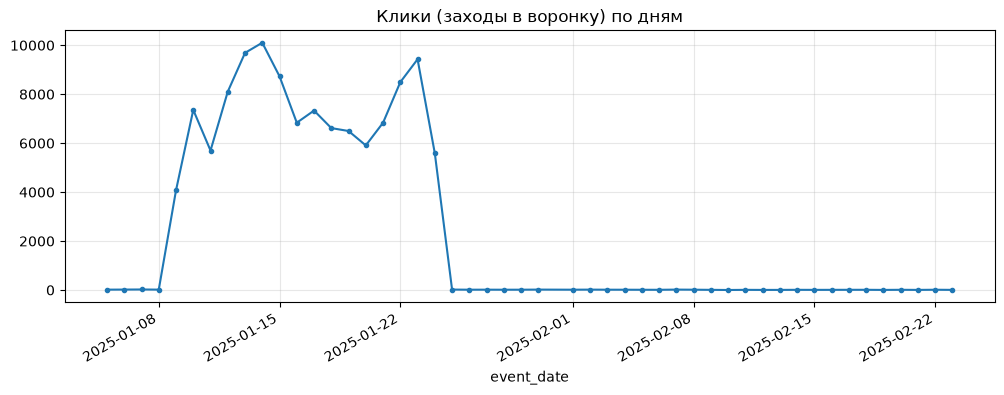

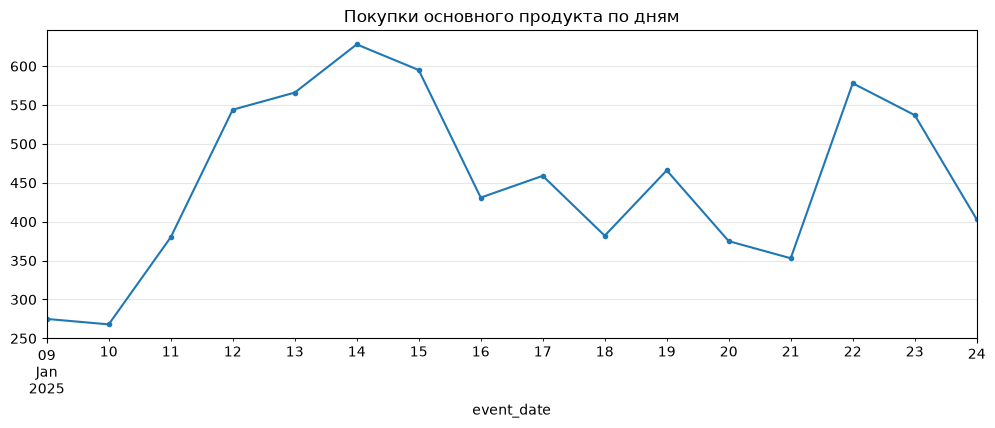

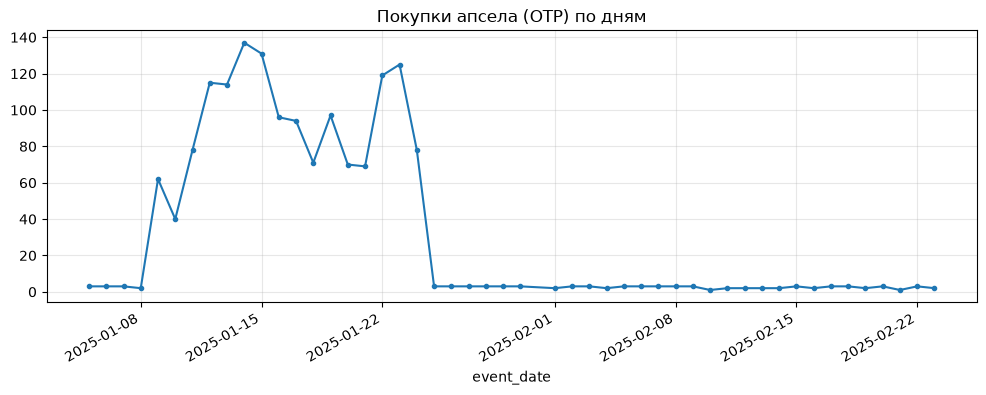

,min,max
event_name,,
click,2025-01-05,2025-02-23
otp_purchase,2025-01-05,2025-02-23
purchase,2025-01-09,2025-01-24


In [26]:
import matplotlib.pyplot as plt

period_start = pd.Timestamp('2025-01-09')
period_end = pd.Timestamp('2025-01-24')

df_test_clean['event_date'] = pd.to_datetime(df_test_clean['event_date'])

events = {
    'click':        'Клики (заходы в воронку)',
    'purchase':     'Покупки основного продукта',
    'otp_purchase': 'Покупки апсела (OTP)',
}

for event, description in events.items():
    daily = (df_test_clean[df_test_clean['event_name'] == event]
             .groupby('event_date')['user_id'].nunique())
    daily.plot(figsize=(12, 4), marker='.', title=f'{description} по дням')
    plt.grid(True, alpha=0.3)
    plt.show()

df_test_clean.groupby('event_name')['event_date'].agg(['min', 'max'])

1) Тест проводили с 2025-01-09 по 2025-01-2024. Есть хвосты до и после, но это незначительные данные, потому просто из не учитываем (проверить)
2) В тесте были дубли, после чистки обнаружил ошибку в тестовой группе test, а именно наличие Tier1 который находиться в тестовой группе имеет product_name weekly 6.99. Количество:6209

In [32]:
# --- Изоляция хвоста (всё, что вне окна 9–24 января) ---
d = df_test_clean['event_date']
tail = df_test_clean[(d < period_start) | (d > period_end)].copy()

# Q1: объём и типы событий (есть ли purchase?)
print("=== Q1: объём и типы событий в хвосте ===")
print("Всего строк:", tail.shape[0])
print(tail['event_name'].value_counts())

# Q2: когда — до 9-го и/или после 24-го
print("\n=== Q2: когда ===")
before = tail[tail['event_date'] < period_start]
after  = tail[tail['event_date'] > period_end]
print(f"До 09.01:    {before.shape[0]} строк  ({before['event_date'].min()} -> {before['event_date'].max()})")
print(f"После 24.01: {after.shape[0]} строк  ({after['event_date'].min()} -> {after['event_date'].max()})")

# Q3: баланс по группам и регионам
print("\n=== Q3: баланс group x country ===")
print(tail.groupby(['group', 'country_group']).size())

# Q4: otp в хвосте — это те самые "сироты" (otp без purchase)?
print("\n=== Q4: otp-сироты ===")
tail_otp_users = set(tail[tail['event_name'] == 'otp_purchase']['user_id'])
purchase_users = set(df_test_clean[df_test_clean['event_name'] == 'purchase']['user_id'])
orphans = tail_otp_users - purchase_users
print("otp-юзеров в хвосте:", len(tail_otp_users))
print("из них НИКОГДА не покупали основной продукт:", len(orphans))

=== Q1: объём и типы событий в хвосте ===
Всего строк: 444
event_name
click           359
otp_purchase     85
Name: count, dtype: int64

=== Q2: когда ===
До 09.01:    82 строк  (2025-01-05 00:00:00 -> 2025-01-08 00:00:00)
После 24.01: 362 строк  (2025-01-25 00:00:00 -> 2025-02-23 00:00:00)

=== Q3: баланс group x country ===
group    country_group
control  EU                75
         Tier1             20
         USA               61
test     EU               130
         Tier1             46
         USA              112
dtype: int64

=== Q4: otp-сироты ===
otp-юзеров в хвосте: 85
из них НИКОГДА не покупали основной продукт: 85


## Блок 0.1: Считае CR

In [28]:



df_period = df_test_clean[
    (df_test_clean['event_date'] >= period_start) &
    (df_test_clean['event_date'] < period_end + pd.Timedelta(days=1))
].copy()

regions = ['EU', 'USA', 'Tier1']
groups = ['control', 'test']

for reg in regions:
    for grp in groups:
        subset = df_period[
            (df_period['country_group'] == reg) &
            (df_period['group'] == grp)
        ]
        clickers = df_period[(df_period['event_name'] == 'click') & (df_period['country_group'] == reg) & (df_period['group'] == grp)]['user_id'].nunique()
        buyers   = df_period[(df_period['event_name'] == 'purchase') & (df_period['country_group'] == reg) & (df_period['group'] == grp)]['user_id'].nunique()
        tier1_test = df_period[(df_period['country_group'] == 'Tier1') & (df_period['group'] == 'test')]
        test_arm   = df_period[df_period['group'] == 'test']
        share = tier1_test['user_id'].nunique() / test_arm['user_id'].nunique()
        print(
            f"{reg} {grp}: "
            f"{subset.shape[0]} строк, "
            f"CR = {round(100*buyers/clickers, 2)}%"
        )
        
print(
            
            #f"Test group misscounting= {round(100*(tier1_test.shape[0].nunique()/df_test_clean[df_test_clean['group'] == 'test'].shape[0].nunique()), 2)}%",
            f"Test group misscounting= {round(100*share, 2)}%"
        )  


EU control: 32356 строк, CR = 5.26%
EU test: 30061 строк, CR = 5.43%
USA control: 26346 строк, CR = 7.05%
USA test: 24516 строк, CR = 7.14%
Tier1 control: 6581 строк, CR = 6.44%
Tier1 test: 6163 строк, CR = 6.92%
Test group misscounting= 10.0%


Tier 1 это фактически A/A тест, который проверяет правильно ли работает механика сплита в тесте. Проверка показывать что идентичная группа показывает шум в 6.89 - 6.42 = 0.47% 
Каждый десятый юзер в твоей «тест»-группе на самом деле платил 6.99, а не 9.99. Вывод из этого:

Вот почему тест нельзя анализировать без разбивки. Если бы ты в лоб сравнил control-vs-test, слив все регионы вместе, 10% «теста» тянули бы результат к старой цене и пачкали вывод. Разбивка по регионам (что ты сделал) эту ловушку обходит.
А в деньгах (это уже Блок 3) те же 10% по старой цене — один из кусков, из-за которых общий рост Revenue выглядит меньше, чем «+42%».

# Блок 1. Обновлённые A/B тест. На базе z-тест

In [29]:
# EU: собери 4 числа своим паттерном фильтра (event_name + country_group + group)

regions = ['EU', 'USA', 'Tier1']

period_start = pd.Timestamp('2025-01-09')
period_end = pd.Timestamp('2025-01-24')
event_date = pd.to_datetime(df_test_clean['event_date'])

df_period = df_test_clean[
    (event_date >= period_start) &
    (event_date < period_end + pd.Timedelta(days=1))
].copy()

for reg in regions:
    clk_c = df_test_clean[(df_test_clean['event_name'] == 'click') & (df_test_clean['country_group'] == reg) & (df_test_clean['group'] == 'control')]['user_id'].nunique()   # кликеры EU control
    buy_c = df_test_clean[(df_test_clean['event_name'] == 'purchase') & (df_test_clean['country_group'] == reg) & (df_test_clean['group'] == 'control')]['user_id'].nunique()   # покупатели EU control
    clk_t = df_test_clean[(df_test_clean['event_name'] == 'click') & (df_test_clean['country_group'] == reg) & (df_test_clean['group'] == 'test')]['user_id'].nunique()    # кликеры EU test
    buy_t = df_test_clean[(df_test_clean['event_name'] == 'purchase') & (df_test_clean['country_group'] == reg) & (df_test_clean['group'] == 'test')]['user_id'].nunique()    # покупатели EU test

    z, p = proportions_ztest(count=[buy_c, buy_t], nobs=[clk_c, clk_t])
    print(f"{reg}: z = {z:.3f}, p = {p:.4f}")


EU: z = -0.885, p = 0.3761
USA: z = -0.344, p = 0.7309
Tier1: z = -1.019, p = 0.3083
